1) Imports + Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

FIG_DIR = "results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Model
L = 32
H = 32
Dh = 128
d = H * Dh

# Hardware
PEAK_FLOPS = 312e12
PEAK_BW = 1.6e12

# Derived ridge point
RIDGE = PEAK_FLOPS / PEAK_BW

2) Large-Scale Context Sweep

In [2]:
T_vals = np.linspace(128, 8192, 40)

3) Operational Intensity vs T (Decode)

In [3]:
def bytes_attention(T, kv_bytes=2):
    return 2 * L * H * Dh * T * kv_bytes

def flops_attention(T):
    return 4 * L * H * T * Dh

def operational_intensity(T, kv_bytes=2):
    return flops_attention(T) / bytes_attention(T, kv_bytes)
AI_vals = [operational_intensity(T) for T in T_vals]

4. Plot AI vs T with Ridge Line

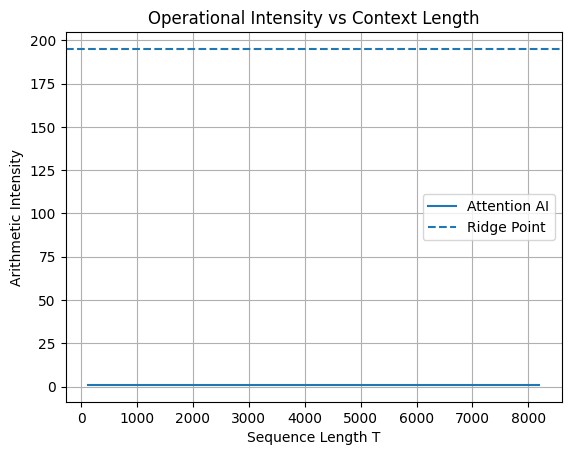

In [4]:
plt.figure()
plt.plot(T_vals, AI_vals)
plt.axhline(RIDGE, linestyle='--')
plt.xlabel("Sequence Length T")
plt.ylabel("Arithmetic Intensity")
plt.title("Operational Intensity vs Context Length")
plt.legend(["Attention AI","Ridge Point"])
plt.grid(True)

plt.savefig(os.path.join(FIG_DIR,"ai_vs_context_extended.png"), dpi=200)
plt.show()

5. Compute-Bound vs Memory-Bound Regions

In [5]:
regime = ["Memory-bound" if ai < RIDGE else "Compute-bound"
          for ai in AI_vals]
for T, ai in zip(T_vals, AI_vals):
    if ai > RIDGE:
        print("Transition at T =", T)
        break

6. Phase Diagram (Very Strong Result)

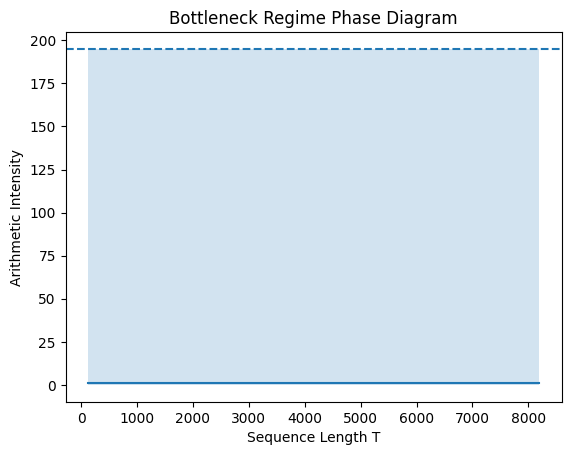

In [6]:
plt.figure()
plt.fill_between(T_vals, 0, RIDGE, alpha=0.2)
plt.plot(T_vals, AI_vals)
plt.axhline(RIDGE, linestyle='--')

plt.xlabel("Sequence Length T")
plt.ylabel("Arithmetic Intensity")
plt.title("Bottleneck Regime Phase Diagram")
plt.savefig(os.path.join(FIG_DIR,"bottleneck_phase_diagram.png"), dpi=200)
plt.show()

7. Overlay Optimizations on Roofline

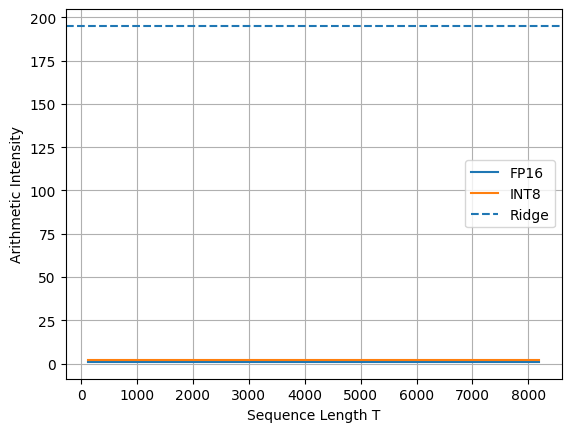

In [7]:
AI_fp16 = [operational_intensity(T, kv_bytes=2) for T in T_vals]
AI_int8 = [operational_intensity(T, kv_bytes=1) for T in T_vals]

plt.figure()
plt.plot(T_vals, AI_fp16)
plt.plot(T_vals, AI_int8)
plt.axhline(RIDGE, linestyle='--')

plt.xlabel("Sequence Length T")
plt.ylabel("Arithmetic Intensity")
plt.legend(["FP16","INT8","Ridge"])
plt.grid(True)

plt.savefig(os.path.join(FIG_DIR,"ai_quantization_comparison.png"), dpi=200)
plt.show()

8) Theoretical Scaling Check

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
for T in [512,2048,8192]:
    print("T=",T," AI=",operational_intensity(T))

T= 512  AI= 1.0
T= 2048  AI= 1.0
T= 8192  AI= 1.0
